# Batch Normalization in Deep Learning

# Import Libraries

In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
from mlxtend.plotting import plot_decision_regions

In [27]:
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_moons

In [28]:
from keras import Sequential
from keras.layers import Dense, Input, BatchNormalization

from keras.optimizers import Adam
from keras.activations import relu, sigmoid

from keras.losses import BinaryCrossentropy

# Make Dataset

In [29]:
X, y = make_moons(n_samples=500, noise=0.1, random_state=0)

## Plot Datatset

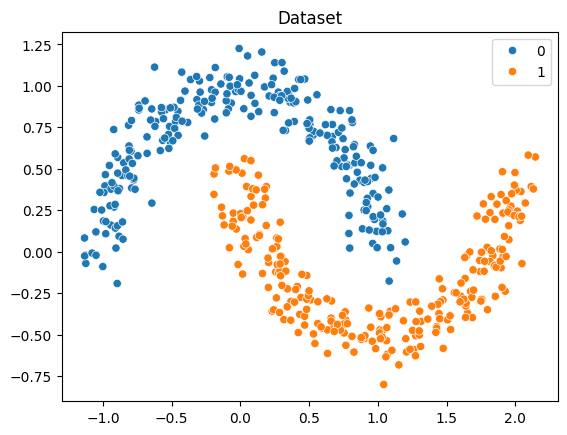

In [30]:
sns.scatterplot(x=X[:,0], y=X[:,1], hue=y)
plt.title('Dataset')
plt.show()

# Train Test Split

In [31]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

# Default Model

## Model Build

In [32]:
model1 = Sequential()

model1.add(Input(shape=(2,)))

model1.add(Dense(10, activation='relu'))
model1.add(Dense(10, activation='relu'))

model1.add(Dense(1, activation='sigmoid'))

In [33]:
model1.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 10)             │            30 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 151 (604.00 B)

 Trainable params: 151 (604.00 B)

 Non-trainable params: 0 (0.00 B)

## Model Training

In [34]:
model1.compile(
    optimizer=Adam(learning_rate=0.01),
    loss=BinaryCrossentropy(),
    metrics=['accuracy']
)

In [35]:
history1 = model1.fit(
    X_train, y_train,
    epochs=300,
    validation_data=(X_test, y_test),
    verbose=0
)

9600/9600 ━━━━━━━━━━━━━━━━━━━━ 7s 702us/step


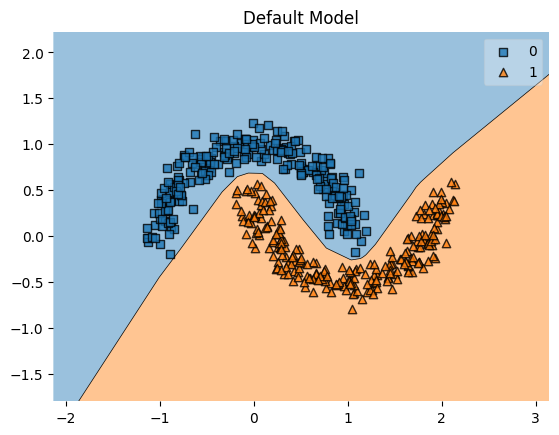

In [36]:
plot_decision_regions(X, y, clf=model1)
plt.title('Default Model')
plt.show()

# Batch Normalized Model

## Model Build

In [37]:
model2 = Sequential()

model2.add(Input(shape=(2,)))

model2.add(Dense(10, activation='relu'))
model2.add(BatchNormalization())

model2.add(Dense(10, activation='relu'))
model2.add(BatchNormalization())

model2.add(Dense(1, activation='sigmoid'))

In [38]:
model2.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_9 (Dense)                 │ (None, 10)             │            30 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 10)             │            40 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 10)             │            40 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 231 (924.00 B)

 Trainable params: 191 (764.00 B)

 Non-trainable params: 40 (160.00 B)

## Model Training

In [39]:
model2.compile(
    optimizer=Adam(learning_rate=0.01),
    loss=BinaryCrossentropy(),
    metrics=['accuracy']
)

In [40]:
history2 = model2.fit(
    X_train, y_train,
    epochs=300,
    batch_size=32,
    validation_data=(X_test, y_test),
    verbose=0
)

9600/9600 ━━━━━━━━━━━━━━━━━━━━ 9s 880us/step


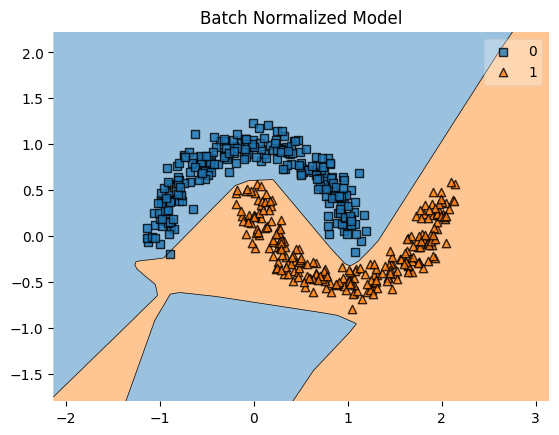

In [41]:
plot_decision_regions(X, y, clf=model2)
plt.title('Batch Normalized Model')
plt.show()

# Compare both model accuracy

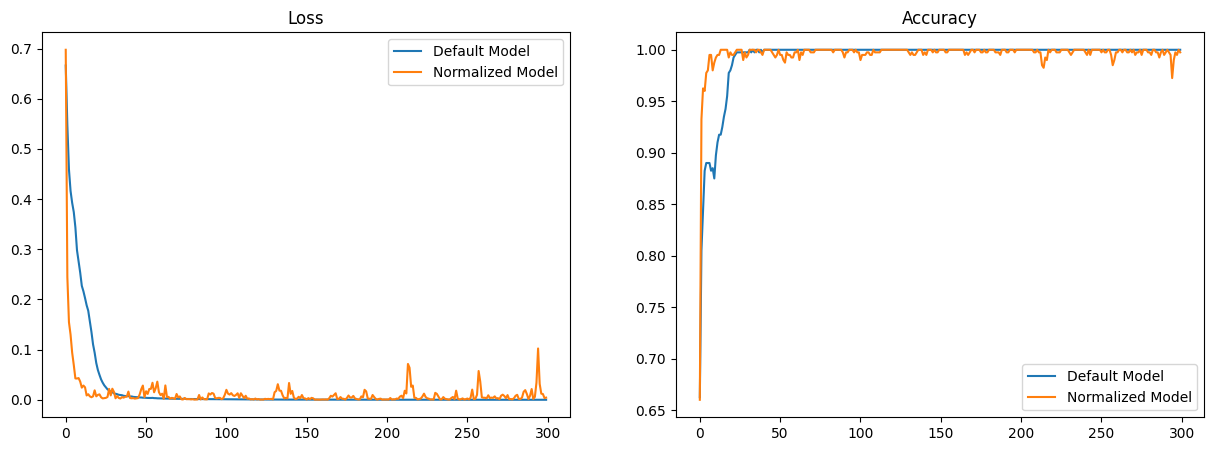

In [42]:
plt.figure(figsize=(15, 5))

plt.subplot(1, 2, 1)
plt.plot(history1.history['loss'], label='Default Model')
plt.plot(history2.history['loss'], label='Normalized Model')
plt.legend()
plt.title('Loss')

plt.subplot(1, 2, 2)
plt.plot(history1.history['accuracy'], label='Default Model')
plt.plot(history2.history['accuracy'], label='Normalized Model')
plt.legend()
plt.title('Accuracy')

plt.show()